In [1]:
import asyncio
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
import sys
from pathlib import Path

# Asumiendo que notebooks/ está dentro de la raíz del proyecto
root_path = Path().resolve().parent  # sube un nivel
sys.path.append(str(root_path))

In [3]:
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent
from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader
import pandas as pd


==================== TEST MULTI-AGENT (WINE + SHAP + LIME) ====================
[Dataset] wine cargado → X=(178, 13), y=(178,)
[Dataset] Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

[Instancia] Índice frontera: 83
[Instancia] Clase real: 1
[Instancia] Probabilidades (RF ref): [0.03 0.73 0.24]
[Instancia] Entropía: 0.6774

[Setup] Inicializando agentes...

[rf_adaptive] Setup iniciado
[rf_adaptive] 00:01:51 | Setup iniciado (train + eval inicial)
[rf_adaptive] 00:01:51 | Entrenando modelo (iter=0)
[rf_adaptive] 00:01:51 | Evaluación completada | acc=0.889
[rf_adaptive] 00:01:51 | Setup completado
[gb_adaptive] Setup iniciado
[gb_adaptive] 00:01:51 | Setup iniciado (train + eval inicial)
[gb_adaptive] 00:01:51 | Entrenando modelo (iter=0)
[gb_adaptive] 00:01:51 | Evaluación completada | acc=0.972
[gb_adaptive] 00:

PermutationExplainer explainer: 2it [00:14, 14.37s/it]               


[rf_adaptive] Explainer shap completado
[rf_adaptive] Iniciando explainer: lime
[rf_adaptive] Explainer lime completado
[rf_adaptive] 00:02:06 | Clasificación completada
[gb_adaptive] 00:02:06 | Clasificando instancia
[gb_adaptive] Iniciando explainer: shap
[gb_adaptive] Explainer shap completado
[gb_adaptive] Iniciando explainer: lime
[gb_adaptive] Explainer lime completado
[gb_adaptive] 00:02:06 | Clasificación completada
[nn_torch] 00:02:06 | Clasificando instancia
[nn_torch] Iniciando explainer: shap
[nn_torch] Explainer shap completado
[nn_torch] Iniciando explainer: lime
[nn_torch] Explainer lime completado
[nn_torch] 00:02:08 | Clasificación completada
[AGGREGATOR] 00:02:08 | Recibidas 3 respuestas
[Aggregator] Majority   = 1
[Aggregator] Scores     = [0.9, 0.893, 0.374]
[Aggregator] Trends     = [0.0, 0.0, 0.0]
[Aggregator] Decisions  = ['keep', 'soft_adjust', 'soft_adjust']
[Aggregator] VotosStop  = [False, False, False]
[Aggregator] Consensus  = 0.615
[Aggregator] Stop       

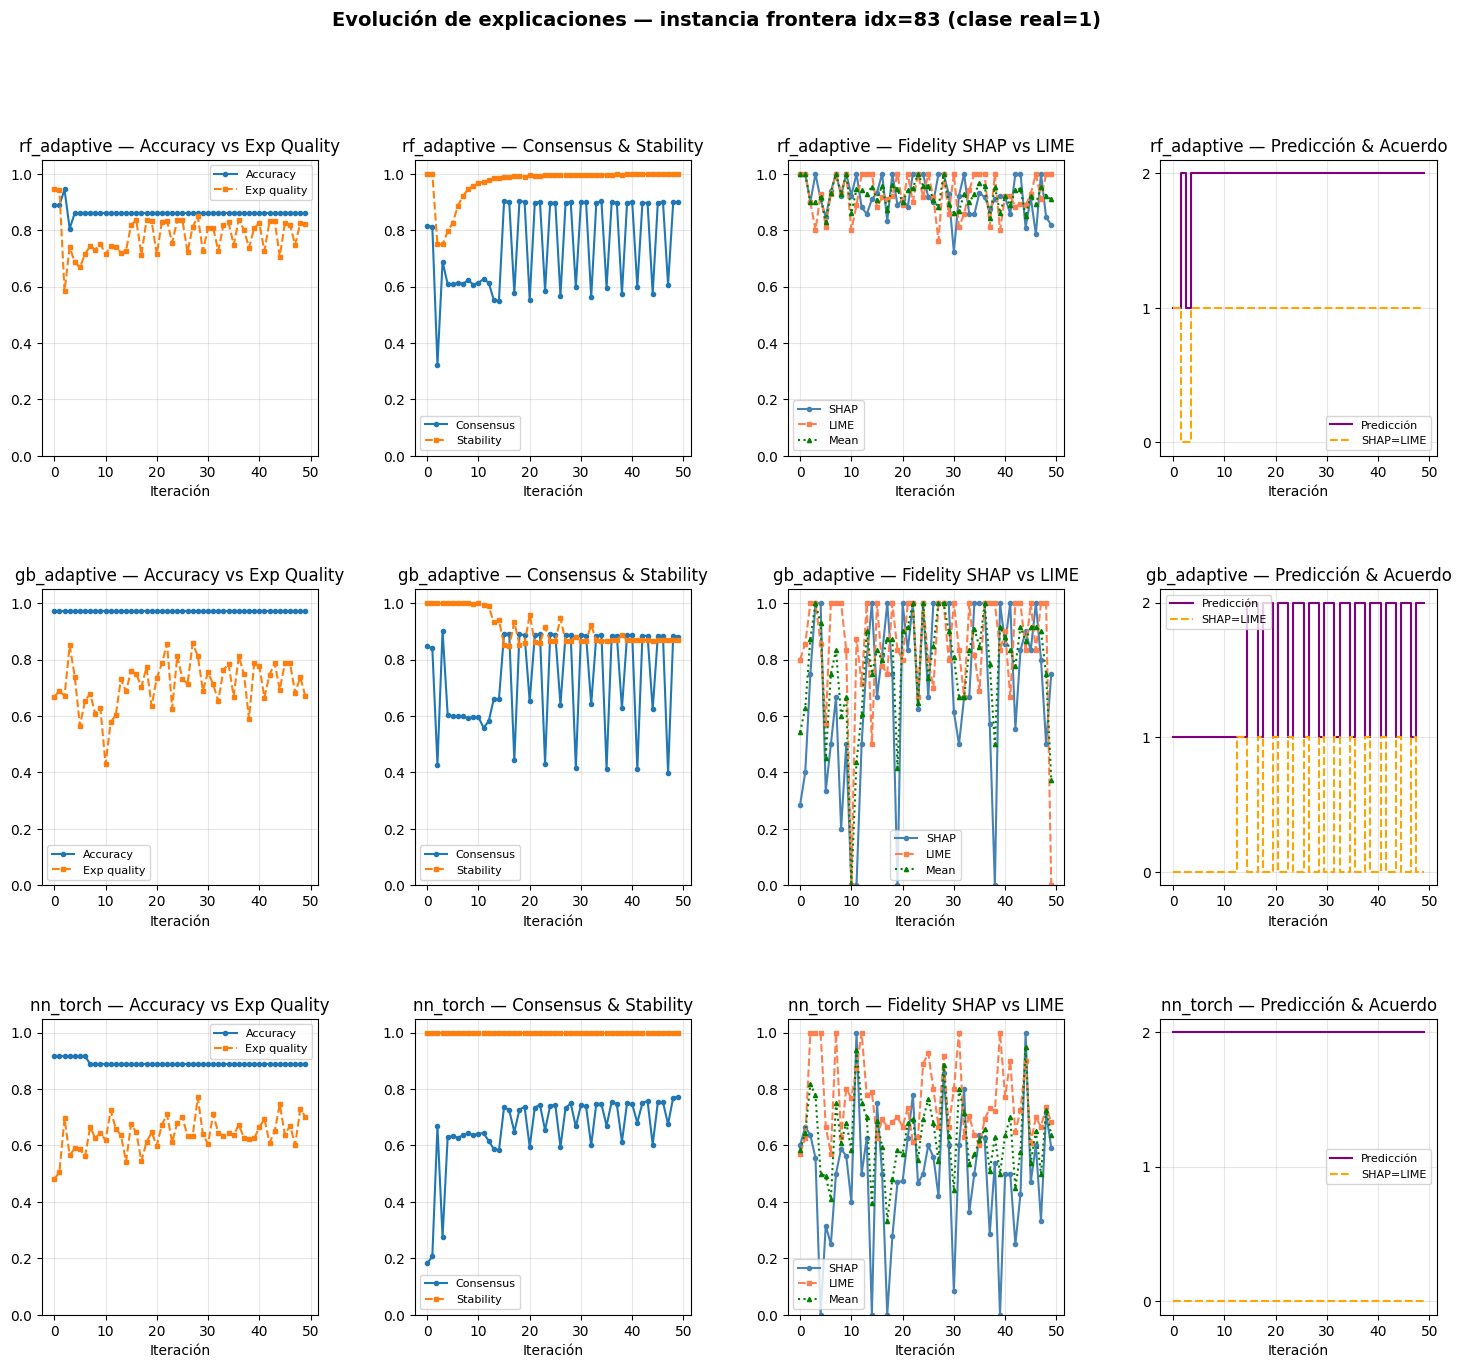


[Resumen] Medias por agente:
             accuracy     f1  exp_quality  exp_consensus  exp_stability  \
agent                                                                     
gb_adaptive     0.972  0.973        0.713          0.733          0.911   
nn_torch        0.893  0.893        0.640          0.662          0.999   
rf_adaptive     0.863  0.863        0.780          0.745          0.972   

             exp_fidelity  exp_agreement  
agent                                     
gb_adaptive         0.776          0.218  
nn_torch            0.627          0.024  
rf_adaptive         0.926          0.238  

[Resumen] Evolución media por iteración (primeras 10):
           accuracy  exp_quality  exp_fidelity  exp_agreement
iteration                                                    
0             0.926        0.697         0.710          0.333
1             0.926        0.713         0.758          0.333
2             0.944        0.650         0.864          0.133
3            

,agent,iteration,accuracy,f1,precision,recall,prediction,confidence,exp_quality,exp_consensus,...,shap_consensus,shap_stability,shap_fidelity,lime_consensus,lime_stability,lime_fidelity,shap_top_feature,lime_top_feature,shap_lime_agree,decision
0,gb_adaptive,0,0.972222,0.972812,0.976190,0.972222,1,0.647642,0.667137,0.847604,...,0.847604,1.000000,0.285712,0.955670,1.000000,0.799995,flavanoids,proline,False,soft_adjust
1,gb_adaptive,1,0.972222,0.972812,0.976190,0.972222,1,0.641056,0.690540,0.840215,...,0.840215,0.999925,0.399998,0.954874,0.999321,0.857136,od280/od315_of_diluted_wines,proline,False,keep
2,gb_adaptive,2,0.972222,0.972812,0.976190,0.972222,1,0.641056,0.670769,0.427874,...,0.427874,0.999871,0.749996,0.968562,0.999457,0.999940,flavanoids,proline,False,soft_adjust
3,gb_adaptive,3,0.972222,0.972812,0.976190,0.972222,1,0.647642,0.850411,0.902038,...,0.902038,0.999887,0.999970,0.985176,0.998565,0.999985,flavanoids,proline,False,keep
4,gb_adaptive,4,0.972222,0.972812,0.976190,0.972222,1,0.647642,0.739437,0.603459,...,0.603459,0.999818,0.999980,0.967938,0.998841,0.857136,flavanoids,proline,False,soft_adjust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,rf_adaptive,45,0.861111,0.861111,0.904514,0.861111,2,0.738660,0.825608,0.897411,...,0.897411,0.998570,0.916662,0.922258,0.998236,0.928567,color_intensity,color_intensity,True,keep
146,rf_adaptive,46,0.861111,0.861111,0.904514,0.861111,2,0.738660,0.817880,0.901345,...,0.901345,0.998635,0.785711,0.919768,0.998326,0.999995,color_intensity,color_intensity,True,keep
147,rf_adaptive,47,0.861111,0.861111,0.904514,0.861111,2,0.738660,0.747979,0.606442,...,0.606442,0.998695,0.999995,0.908202,0.998777,0.909086,color_intensity,color_intensity,True,keep
148,rf_adaptive,48,0.861111,0.861111,0.904514,0.861111,2,0.738660,0.826097,0.898797,...,0.898797,0.998751,0.846150,0.910484,0.997536,0.999995,color_intensity,color_intensity,True,keep


In [4]:
import asyncio
import numpy as np
import torch
import pandas as pd

from sklearn.datasets import load_wine

from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader

from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent

from explainers.shap_explainer import ShapExplainer
from explainers.lime_explainer import LimeExplainer

from models.torch_model import TorchModel
from models.random_forest import RandomForest
from models.gradient_boosting import GradientBoostingModel

from visualization.visualization import (
    plot_metrics_over_time,
    plot_explanation_similarity,
    plot_explanation_divergence,
    plot_agents_dashboard
)
from visualization.logs import log

import torch.nn as nn


class SmallMLP(nn.Module):
    def __init__(self, input_dim=13, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def _top_feature(explanation, feature_names):
    """Devuelve el nombre de la feature con mayor magnitud en la explicación."""
    if explanation is None:
        return None
    try:
        values = np.array(explanation["details"]["values"])
        idx = int(np.argmax(np.abs(values)))
        if feature_names and idx < len(feature_names):
            return feature_names[idx]
        return f"f{idx}"
    except Exception:
        return None


async def run_test():
    print("\n==================== TEST MULTI-AGENT (WINE + SHAP + LIME) ====================")

    # ------------------- Dataset -------------------
    registry = DatasetRegistry()
    dataset_id = "wine"
    registry.register(dataset_id, SklearnLoader(load_wine))

    X, y, meta = registry.load(dataset_id)
    feature_names = list(meta["feature_names"])
    class_names   = [str(c) for c in np.unique(y)]

    print(f"[Dataset] {dataset_id} cargado → X={X.shape}, y={y.shape}")
    print(f"[Dataset] Features: {feature_names}")

    # -------------------------------------------------------
    # Instancia frontera — máxima entropía de predicción
    # -------------------------------------------------------
    from sklearn.ensemble import RandomForestClassifier as _RFC
    from sklearn.preprocessing import StandardScaler

    _rf_tmp  = _RFC(n_estimators=100, random_state=42).fit(X, y)
    _proba   = _rf_tmp.predict_proba(X)
    _entropy = -np.sum(_proba * np.log(_proba + 1e-8), axis=1)
    hard_idx = int(np.argmax(_entropy))

    print(f"\n[Instancia] Índice frontera: {hard_idx}")
    print(f"[Instancia] Clase real: {y[hard_idx]}")
    print(f"[Instancia] Probabilidades (RF ref): {_proba[hard_idx].round(3)}")
    print(f"[Instancia] Entropía: {_entropy[hard_idx]:.4f}")

    # -------------------------------------------------------
    # Normalización
    # -------------------------------------------------------
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    instance = X_scaled[hard_idx:hard_idx + 1]

    class ScaledWineLoader:
        def __init__(self, X, y, feature_names):
            self.X = X
            self.y = y
            self.feature_names = feature_names
        def load(self):
            return self.X, self.y, {
                "feature_names": self.feature_names,
                "n_samples":     self.X.shape[0],
                "n_features":    self.X.shape[1]
            }

    registry2 = DatasetRegistry()
    registry2.register("wine_scaled", ScaledWineLoader(X_scaled, y, feature_names))

    # -------------------------------------------------------
    # Explainers
    # -------------------------------------------------------
    def make_explainers():
        return [
            ShapExplainer(feature_names=feature_names),
            LimeExplainer(
                feature_names=feature_names,
                class_names=class_names,
                discretize_continuous=False
            )
        ]

    # -------------------------------------------------------
    # Modelos — arrancan débiles para tener recorrido de mejora
    # -------------------------------------------------------
    rf_model = RandomForest(
        n_estimators=5,
        max_depth=2,
        random_state=0
    )

    gb_model = GradientBoostingModel(
        n_estimators=5,
        learning_rate=0.9,
        max_depth=1
    )

    torch_model = TorchModel(
        nn_model=SmallMLP(input_dim=X.shape[1], num_classes=len(np.unique(y))),
        lr=1e-3,
        min_lr=1e-5,
        max_lr=0.05,
        epochs=20,
        batch_size=16
    )

    # -------------------------------------------------------
    # Clasificadores
    # -------------------------------------------------------
    classifiers = {
        "rf_adaptive": ClassifierAgent(
            agent_id="rf_adaptive",
            model=rf_model,
            explainers=make_explainers(),
            dataset_id="wine_scaled",
            registry=registry2
        ),
        "gb_adaptive": ClassifierAgent(
            agent_id="gb_adaptive",
            model=gb_model,
            explainers=make_explainers(),
            dataset_id="wine_scaled",
            registry=registry2
        ),
        "nn_torch": ClassifierAgent(
            agent_id="nn_torch",
            model=torch_model,
            explainers=make_explainers(),
            dataset_id="wine_scaled",
            registry=registry2
        )
    }

    classifier_ids = list(classifiers.keys())

    aggregator = AggregatorAgent(
        classifier_ids=classifier_ids,
        alpha=0.4,
        beta=0.15,
        gamma=0.25,
        max_iterations=50,
        background_data=X_scaled
    )

    queues = {cid: agent.inbox for cid, agent in classifiers.items()}
    queues["aggregator"] = aggregator.inbox

    print("\n[Setup] Inicializando agentes...\n")
    await asyncio.gather(*(agent.setup() for agent in classifiers.values()))
    log("Inicializando AggregatorAgent")

    tasks = [
        asyncio.create_task(agent.run(queues))
        for agent in classifiers.values()
    ]
    tasks.append(
        asyncio.create_task(aggregator.run(queues, instance))
    )

    await asyncio.gather(*tasks, return_exceptions=True)

    # =========================================================
    # DataFrame — igual que antes
    # =========================================================
    rows = []

    for entry in aggregator.global_history:
        iteration     = entry["iteration"]
        evaluation    = entry["evaluation"]
        exp_detail    = evaluation["components"]["exp_detail"]
        per_explainer = exp_detail.get("per_explainer", {})
        decisions     = entry["decisions"]

        for idx, agent_id in enumerate(classifier_ids):
            explanations = entry["responses"][idx].get("explanations", [])

            shap_exp = next((e for e in explanations if e.get("explainer") == "shap"), None)
            lime_exp = next((e for e in explanations if e.get("explainer") == "lime"), None)

            shap_top = _top_feature(shap_exp, feature_names)
            lime_top = _top_feature(lime_exp, feature_names)

            def _get(name, metric):
                arr = per_explainer.get(name, {}).get(metric, [])
                return arr[idx] if idx < len(arr) else None

            row = {
                "agent":            agent_id,
                "iteration":        iteration,
                "accuracy":         entry["responses"][idx]["metrics"]["accuracy"],
                "f1":               entry["responses"][idx]["metrics"]["f1"],
                "precision":        entry["responses"][idx]["metrics"]["precision"],
                "recall":           entry["responses"][idx]["metrics"]["recall"],
                "prediction":       entry["responses"][idx]["prediction"],
                "confidence":       entry["responses"][idx].get("confidence", None),
                "exp_quality":      exp_detail["quality"][idx],
                "exp_consensus":    exp_detail["consensus"][idx],
                "exp_stability":    exp_detail["stability"][idx],
                "exp_fidelity":     exp_detail["fidelity"][idx],
                "exp_agreement":    exp_detail["agreement"][idx],
                "shap_consensus":   _get("shap", "consensus"),
                "shap_stability":   _get("shap", "stability"),
                "shap_fidelity":    _get("shap", "fidelity"),
                "lime_consensus":   _get("lime", "consensus"),
                "lime_stability":   _get("lime", "stability"),
                "lime_fidelity":    _get("lime", "fidelity"),
                "shap_top_feature": shap_top,
                "lime_top_feature": lime_top,
                "shap_lime_agree":  shap_top == lime_top and shap_top is not None,
                "decision":         decisions[idx],
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    df_sorted = df.sort_values(["agent", "iteration"]).reset_index(drop=True)

    # =========================================================
    # Visualización
    # =========================================================
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    n_agents = len(classifier_ids)
    fig = plt.figure(figsize=(18, 5 * n_agents))
    fig.suptitle(
        f"Evolución de explicaciones — instancia frontera idx={hard_idx} "
        f"(clase real={y[hard_idx]})",
        fontsize=14, fontweight="bold"
    )
    gs = gridspec.GridSpec(n_agents, 4, figure=fig, hspace=0.45, wspace=0.35)

    for row_i, agent_id in enumerate(classifier_ids):
        sub   = df_sorted[df_sorted["agent"] == agent_id].reset_index(drop=True)
        iters = sub["iteration"]

        ax = fig.add_subplot(gs[row_i, 0])
        ax.plot(iters, sub["accuracy"],    label="Accuracy",    marker="o", markersize=3)
        ax.plot(iters, sub["exp_quality"], label="Exp quality", marker="s", markersize=3, linestyle="--")
        ax.set_title(f"{agent_id} — Accuracy vs Exp Quality")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = fig.add_subplot(gs[row_i, 1])
        ax.plot(iters, sub["exp_consensus"], label="Consensus", marker="o", markersize=3)
        ax.plot(iters, sub["exp_stability"], label="Stability",  marker="s", markersize=3, linestyle="--")
        ax.set_title(f"{agent_id} — Consensus & Stability")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = fig.add_subplot(gs[row_i, 2])
        ax.plot(iters, sub["shap_fidelity"], label="SHAP",      marker="o", markersize=3, color="steelblue")
        ax.plot(iters, sub["lime_fidelity"], label="LIME",      marker="s", markersize=3, color="coral", linestyle="--")
        ax.plot(iters, sub["exp_fidelity"],  label="Mean",      marker="^", markersize=3, color="green", linestyle=":")
        ax.set_title(f"{agent_id} — Fidelity SHAP vs LIME")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = fig.add_subplot(gs[row_i, 3])
        ax.step(iters, sub["prediction"],                label="Predicción",    where="mid", color="purple")
        ax.step(iters, sub["shap_lime_agree"].astype(int), label="SHAP=LIME",  where="mid", color="orange", linestyle="--")
        ax.set_title(f"{agent_id} — Predicción & Acuerdo")
        ax.set_yticks([0, 1, 2])
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.show()

    # =========================================================
    # Resúmenes
    # =========================================================
    print("\n[Resumen] Medias por agente:")
    print(df_sorted.groupby("agent")[[
        "accuracy", "f1", "exp_quality", "exp_consensus",
        "exp_stability", "exp_fidelity", "exp_agreement"
    ]].mean().round(3))

    print("\n[Resumen] Evolución media por iteración (primeras 10):")
    print(df_sorted.groupby("iteration")[[
        "accuracy", "exp_quality", "exp_fidelity", "exp_agreement"
    ]].mean().round(3).head(10))

    print("\n[Resumen] Distribución de decisiones por agente:")
    print(df_sorted.groupby(["agent", "decision"]).size().unstack(fill_value=0))

    print("\n[Resumen] Acuerdo SHAP vs LIME por agente (% iteraciones):")
    print(df_sorted.groupby("agent")["shap_lime_agree"].mean().round(3))

    print("\n[Resumen] Fidelity media SHAP vs LIME por agente:")
    print(df_sorted.groupby("agent")[["shap_fidelity", "lime_fidelity"]].mean().round(3))

    print("\n[Resumen] Feature más votada por SHAP y LIME:")
    for agent_id in classifier_ids:
        sub = df_sorted[df_sorted["agent"] == agent_id]
        print(f"\n  {agent_id}:")
        print(f"    SHAP top: {sub['shap_top_feature'].value_counts().head(3).to_dict()}")
        print(f"    LIME top: {sub['lime_top_feature'].value_counts().head(3).to_dict()}")

    print("\n[Análisis] Correlación Accuracy ↔ Exp Quality por agente:")
    for agent_id in classifier_ids:
        sub  = df_sorted[df_sorted["agent"] == agent_id]
        corr = sub["accuracy"].corr(sub["exp_quality"])
        print(f"  {agent_id}: r={corr:.3f}")

    print("\n[Análisis] Predicción por agente e iteración:")
    print(df_sorted.pivot(index="iteration", columns="agent", values="prediction").to_string())

    print("\n[Análisis] Estabilización de predicción:")
    for agent_id in classifier_ids:
        preds   = df_sorted[df_sorted["agent"] == agent_id]["prediction"].values
        changes = np.where(np.diff(preds) != 0)[0]
        if len(changes) == 0:
            print(f"  {agent_id}: estable desde iter 0 → pred={preds[0]}")
        else:
            print(f"  {agent_id}: último cambio en iter {changes[-1]+1} → pred final={preds[-1]}")

    print("\n[Análisis] Correlación SHAP consensus ↔ LIME consensus por agente:")
    for agent_id in classifier_ids:
        sub  = df_sorted[df_sorted["agent"] == agent_id]
        corr = sub["shap_consensus"].corr(sub["lime_consensus"])
        print(f"  {agent_id}: r={corr:.3f}")

    return df_sorted


await run_test()